# 2.8 — Gradient Bandit Algorithms

---

## A different idea entirely

Every method so far estimated $q_*(a)$ and then acted greedily-ish on the estimates.
Here we abandon value estimation. We learn a **numerical preference** $H_t(a)$ for each
action, which has *no interpretation as a reward*. Only the relative differences matter.

Actions are chosen by a **soft-max (Gibbs / Boltzmann) distribution**:

$$\pi_t(a) \;\doteq\; P\{A_t = a\} \;=\; \frac{e^{H_t(a)}}{\sum_{b=1}^{k} e^{H_t(b)}}$$

Initially $H_1(a) = 0$ for all $a$, so all actions are equally likely.

## The learning rule

After taking $A_t$ and receiving $R_t$:

$$
\begin{aligned}
H_{t+1}(A_t) &\doteq H_t(A_t) + \alpha\big(R_t - \bar{R}_t\big)\big(1 - \pi_t(A_t)\big) \\[4pt]
H_{t+1}(a) &\doteq H_t(a) - \alpha\big(R_t - \bar{R}_t\big)\pi_t(a), \qquad \forall a \neq A_t
\end{aligned}
$$

where $\bar{R}_t$ is the average of all rewards so far — the **baseline**.

Read it in plain terms: if the reward beat the baseline, make the action you took more
likely and everything else less likely; if it fell short, do the reverse. The
$(1-\pi_t(A_t))$ and $\pi_t(a)$ factors size the adjustment by how surprising the choice
was — an action you were already going to take almost surely barely moves.

## Why this is *gradient* ascent

The claim is that this is stochastic gradient ascent on expected reward:

$$H_{t+1}(a) \;=\; H_t(a) + \alpha \frac{\partial\, \mathbb{E}[R_t]}{\partial H_t(a)}, \qquad
\mathbb{E}[R_t] = \sum_x \pi_t(x)\, q_*(x)$$

Sketch of the derivation (the book does it in full):

$$
\begin{aligned}
\frac{\partial \mathbb{E}[R_t]}{\partial H_t(a)}
&= \sum_x q_*(x)\frac{\partial \pi_t(x)}{\partial H_t(a)} \\
&= \sum_x \big(q_*(x) - B_t\big)\frac{\partial \pi_t(x)}{\partial H_t(a)}
&&\text{since } \sum_x \tfrac{\partial \pi_t(x)}{\partial H_t(a)} = 0 \\
&= \sum_x \pi_t(x)\big(q_*(x) - B_t\big)\frac{\partial \pi_t(x)}{\partial H_t(a)} \big/ \pi_t(x)
&&\text{multiply and divide} \\
&= \mathbb{E}\!\left[\big(R_t - B_t\big)\big(\mathbb{1}_{a = A_t} - \pi_t(a)\big)\right]
&&\text{using } \tfrac{\partial \pi_t(x)}{\partial H_t(a)} = \pi_t(x)(\mathbb{1}_{a=x} - \pi_t(a))
\end{aligned}
$$

Substituting the sample for the expectation and $\bar{R}_t$ for $B_t$ gives exactly the
update above. **The algorithm is an unbiased stochastic gradient estimate** — so it
inherits the convergence guarantees of stochastic gradient ascent.

## The baseline is free — and it matters enormously

The second line above is the crucial one: **any** $B_t$ that does not depend on $x$
leaves the gradient unchanged, because $\sum_x \frac{\partial \pi_t(x)}{\partial H_t(a)} = 0$
(the probabilities must always sum to 1). So the baseline does not bias the update at
all — it only changes its **variance**. Choosing $B_t = \bar{R}_t$ dramatically reduces
that variance, which is the whole point.

This is the ancestor of the baseline in REINFORCE and of the critic in actor-critic
methods (Chapter 13).

In [1]:
import sys, os
sys.path.insert(0, os.getcwd())

import numpy as np
import matplotlib.pyplot as plt
from bandit_utils import (Testbed, run_bandit, plot_pair, argmax_random_tiebreak,
                          hide, banner, RUNS, STEPS)

plt.rcParams["figure.dpi"] = 110
banner()

mode=FULL  runs=2000  steps=1000
switch with:  import os; os.environ['RL_MODE']='FULL'  (before importing)


In [2]:
class GradientBandit:
    def __init__(self, k, runs, rng, alpha=0.1, baseline=True):
        self.k, self.runs, self.rng = k, runs, rng
        self.alpha, self.use_baseline = alpha, baseline
        self.H = np.zeros((runs, k))
        self.Rbar = np.zeros(runs)
        self.t = 0
        self.pi = np.full((runs, k), 1.0 / k)

    def act(self):
        e = np.exp(self.H - self.H.max(axis=1, keepdims=True))
        self.pi = e / e.sum(axis=1, keepdims=True)
        u = self.rng.random((self.runs, 1))
        return (self.pi.cumsum(axis=1) < u).sum(axis=1)

    def update(self, a, r):
        self.t += 1
        base = self.Rbar if self.use_baseline else 0.0
        adv = (r - base)[:, None]
        onehot = np.zeros_like(self.H)
        onehot[np.arange(self.runs), a] = 1.0
        self.H += self.alpha * adv * (onehot - self.pi)
        if self.use_baseline:
            self.Rbar += (r - self.Rbar) / self.t


def grad_agent(alpha, baseline=True):
    return lambda k, runs, rng: GradientBandit(k, runs, rng, alpha=alpha,
                                               baseline=baseline)

print("agent defined")

agent defined


## The soft-max, before anything else

Get an intuition for how preferences map to probabilities. Note that the map is
*shift-invariant* — adding a constant to every $H(a)$ changes nothing — so only
differences matter.

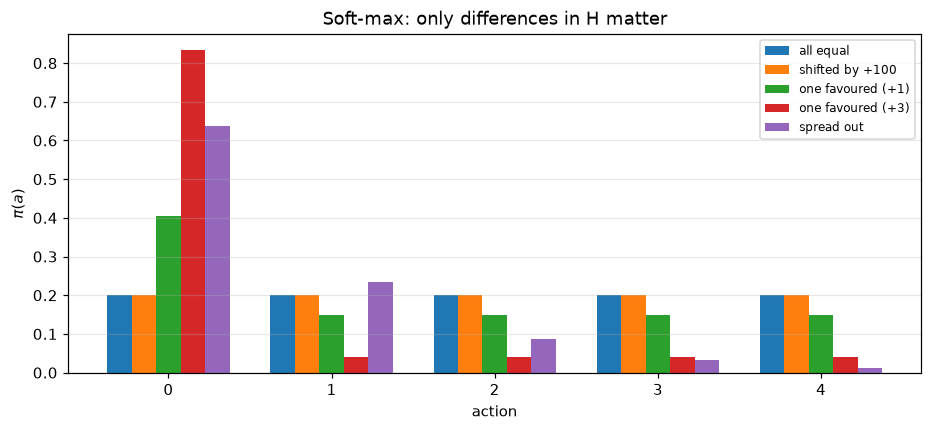

preference gap -> probability ratio:
  H difference 0.5  ->       1.6x more likely
  H difference 1  ->       2.7x more likely
  H difference 2  ->       7.4x more likely
  H difference 3  ->      20.1x more likely
  H difference 5  ->     148.4x more likely


In [3]:
def softmax(H):
    e = np.exp(H - H.max())
    return e / e.sum()

H_examples = {
    "all equal": np.zeros(5),
    "shifted by +100": np.zeros(5) + 100,
    "one favoured (+1)": np.array([1., 0, 0, 0, 0]),
    "one favoured (+3)": np.array([3., 0, 0, 0, 0]),
    "spread out": np.array([2., 1, 0, -1, -2]),
}
fig, ax = plt.subplots(figsize=(10, 4))
w = 0.15
for i, (lab, H) in enumerate(H_examples.items()):
    ax.bar(np.arange(5) + (i - 2) * w, softmax(H), w, label=lab)
ax.set_xticks(range(5)); ax.set_xlabel("action"); ax.set_ylabel("$\\pi(a)$")
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis="y")
ax.set_title("Soft-max: only differences in H matter")
plt.show()

print("preference gap -> probability ratio:")
for gap in [0.5, 1, 2, 3, 5]:
    print(f"  H difference {gap}  ->  {np.exp(gap):8.1f}x more likely")

---

### Predict first

Figure 2.5 uses a **shifted** testbed: $q_*(a) \sim \mathcal{N}(+4, 1)$, so
all rewards are around $+4$ rather than around $0$. We compare $\alpha \in \{0.1, 0.4\}$,
with and without the baseline.

1. Why shift the mean to $+4$? What would this experiment fail to show at mean 0?
2. Without a baseline, will the algorithm still work at all? Better or worse?
3. Which $\alpha$ will do better *with* the baseline? Which *without*?

*Write your guess down (mentally or in the cell below) before running the next cell. The point is not to be right — it is to make the surprise informative when you are wrong.*

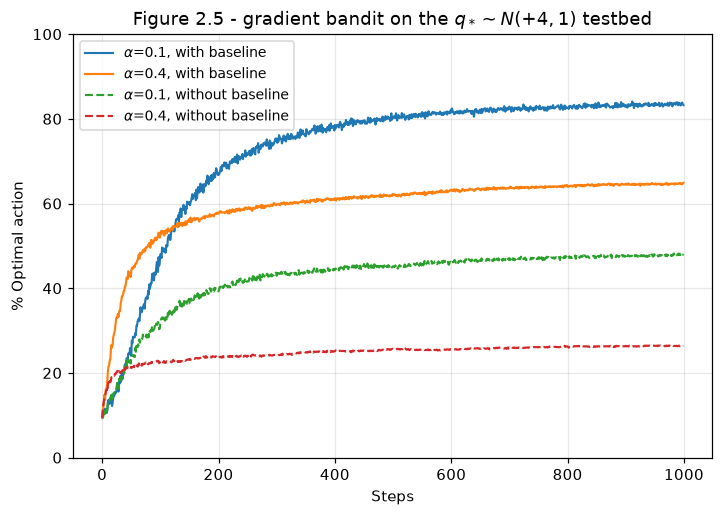

$\alpha$=0.1, with baseline        %opt last 100 =  83.4
$\alpha$=0.4, with baseline        %opt last 100 =  64.6
$\alpha$=0.1, without baseline     %opt last 100 =  47.7
$\alpha$=0.4, without baseline     %opt last 100 =  26.4


In [4]:
kw = {"mean_shift": 4.0}
configs = [(0.1, True), (0.4, True), (0.1, False), (0.4, False)]
res, labs = [], []
for a, b in configs:
    res.append(run_bandit(grad_agent(a, b), testbed_kwargs=kw, seed=21))
    labs.append(f"$\\alpha$={a}, {'with' if b else 'without'} baseline")

fig, axes = plt.subplots(figsize=(7.5, 5))
for r, l, style in zip(res, labs, ["-", "-", "--", "--"]):
    axes.plot(r["optimal"], style, lw=1.4, label=l)
axes.set_xlabel("Steps"); axes.set_ylabel("% Optimal action")
axes.set_ylim(0, 100); axes.legend(fontsize=9); axes.grid(alpha=0.3)
axes.set_title("Figure 2.5 - gradient bandit on the $q_* \\sim N(+4,1)$ testbed")
plt.show()

for l, r in zip(labs, res):
    print(f"{l:<34} %opt last 100 = {r['optimal'][-100:].mean():5.1f}")

In [5]:
hide('''<b>1.</b> The shift to +4 is the entire experimental design. With rewards centred
at 0, the raw reward R_t is <i>already</i> roughly centred, so it doubles as its own
baseline and the no-baseline version looks fine. Shifting to +4 breaks that coincidence
and exposes what the baseline is really for.
<br><br><b>2.</b> Without a baseline it still improves, but much more slowly. Every reward
is now around +4, i.e. positive, so every action taken gets its preference
<i>increased</i> &mdash; including bad ones. The algorithm can only learn from the
<i>relative</i> sizes of those increases, which is a far weaker signal. Formally, the
gradient estimate is unbiased either way, but its variance is enormous when the baseline
is wrong.
<br><br><b>3.</b> With a baseline, &alpha;=0.1 wins (0.4 overshoots and is noisy). Without
a baseline the ordering can flip &mdash; the larger step size partly compensates for the
weaker signal. The general pattern: a bad baseline forces you to retune everything else.''')

## The baseline as variance reduction — measured

The claim is that $B_t$ does not change the *expected* update, only its variance. That is
falsifiable. Let us measure both.

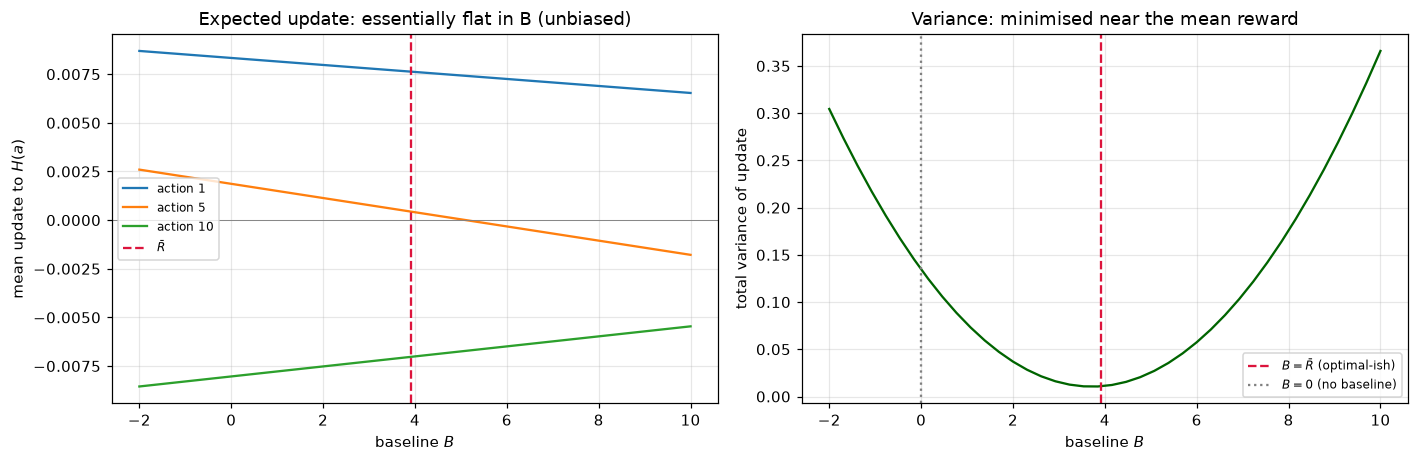

variance with B=0: 0.13471   with B=Rbar: 0.01085   ratio 12.4x


In [6]:
def gradient_variance(baseline_value, k=10, alpha=0.1, samples=40000, seed=0):
    rng = np.random.default_rng(seed)
    q = np.array([4.5, 4.2, 4.0, 3.9, 3.8, 3.7, 3.5, 3.4, 3.2, 3.0])[:k]
    H = np.zeros(k); pi = np.full(k, 1 / k)
    a = rng.choice(k, size=samples, p=pi)
    r = rng.normal(q[a], 1.0)
    onehot = np.zeros((samples, k)); onehot[np.arange(samples), a] = 1
    upd = alpha * (r - baseline_value)[:, None] * (onehot - pi)
    return upd.mean(axis=0), upd.var(axis=0).sum()

true_mean = 3.92
baselines = np.linspace(-2, 10, 40)
means, variances = [], []
for b in baselines:
    m, v = gradient_variance(b)
    means.append(m); variances.append(v)
means = np.array(means)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
for a in [0, 4, 9]:
    axes[0].plot(baselines, means[:, a], label=f"action {a+1}")
axes[0].axvline(true_mean, color="crimson", ls="--", label="$\\bar{R}$")
axes[0].axhline(0, color="gray", lw=0.6)
axes[0].set_xlabel("baseline $B$"); axes[0].set_ylabel("mean update to $H(a)$")
axes[0].set_title("Expected update: essentially flat in B (unbiased)")

axes[1].plot(baselines, variances, color="darkgreen")
axes[1].axvline(true_mean, color="crimson", ls="--", label="$B = \\bar{R}$ (optimal-ish)")
axes[1].axvline(0, color="gray", ls=":", label="$B = 0$ (no baseline)")
axes[1].set_xlabel("baseline $B$"); axes[1].set_ylabel("total variance of update")
axes[1].set_title("Variance: minimised near the mean reward")
for ax in axes: ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

_, v0 = gradient_variance(0.0)
_, vb = gradient_variance(true_mean)
print(f"variance with B=0: {v0:.5f}   with B=Rbar: {vb:.5f}   ratio {v0/vb:.1f}x")

Left panel: the expected update barely moves as $B$ sweeps from $-2$ to $+10$. (It is
*exactly* constant in theory; the wiggle is Monte Carlo error.) Right panel: the variance
is a parabola minimised near $\bar{R}$, and using $B=0$ instead costs an order of
magnitude.

**This is the entire argument for baselines, critics, and advantage functions in one
picture.** $A(s,a) = Q(s,a) - V(s)$ in actor-critic is the same move: subtract something
that does not depend on the action, keep the gradient, kill the variance.

## Watching preferences separate

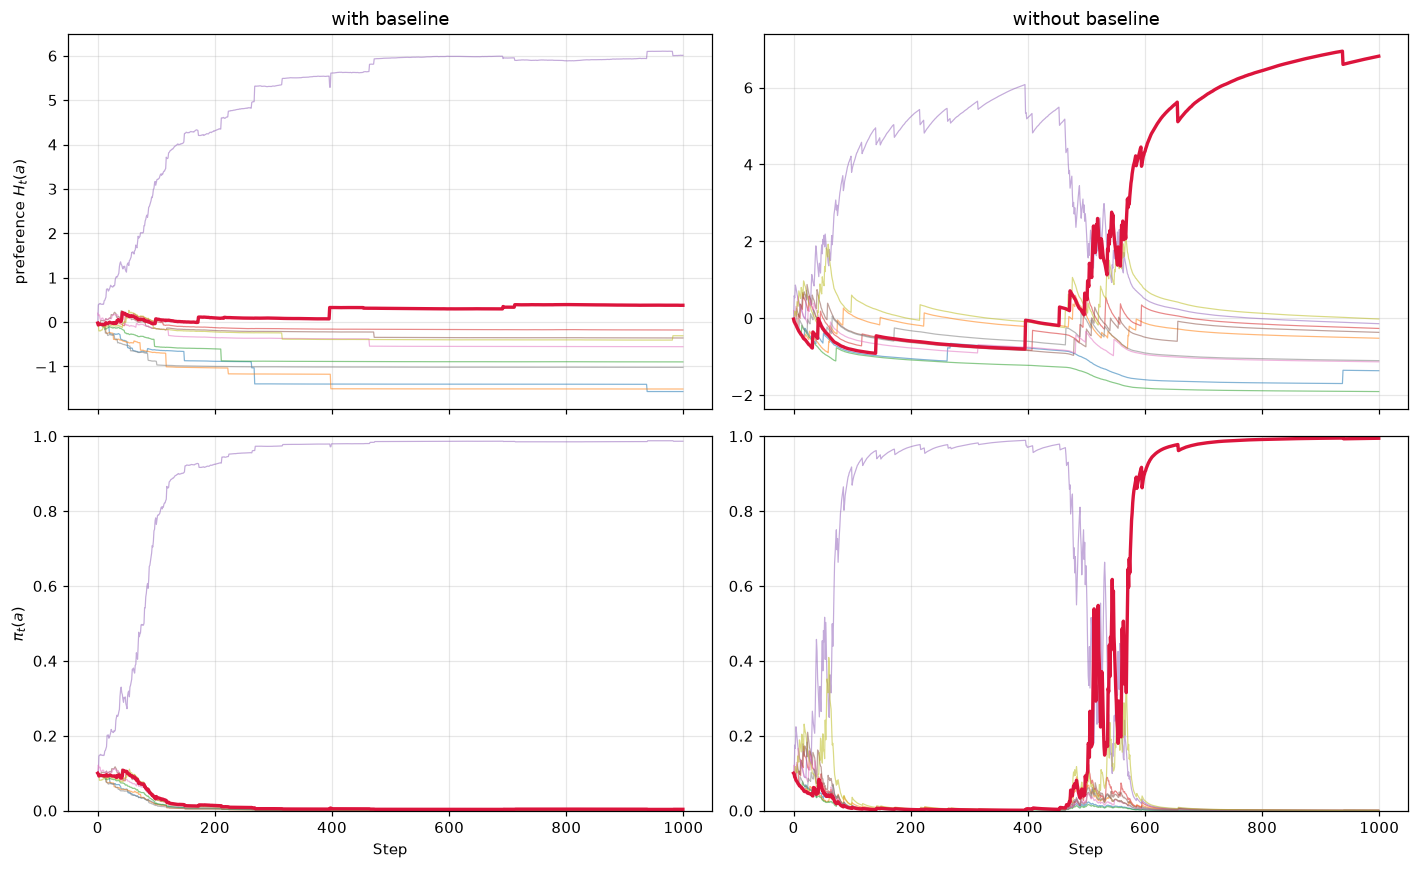

In [7]:
def grad_trace(alpha=0.1, baseline=True, steps=1000, seed=5, shift=4.0):
    rng = np.random.default_rng(seed)
    q = rng.normal(shift, 1, size=10)
    H = np.zeros(10); Rbar = 0.0
    Hh, Ph = [], []
    for t in range(1, steps + 1):
        e = np.exp(H - H.max()); pi = e / e.sum()
        a = rng.choice(10, p=pi)
        r = rng.normal(q[a], 1.0)
        base = Rbar if baseline else 0.0
        oh = np.zeros(10); oh[a] = 1
        H += alpha * (r - base) * (oh - pi)
        Rbar += (r - Rbar) / t
        Hh.append(H.copy()); Ph.append(pi.copy())
    return q, np.array(Hh), np.array(Ph)

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
for col, bl in enumerate([True, False]):
    q, Hh, Ph = grad_trace(baseline=bl)
    best = q.argmax()
    for a in range(10):
        st = dict(lw=2.2, color="crimson") if a == best else dict(lw=0.8, alpha=0.55)
        axes[0, col].plot(Hh[:, a], **st)
        axes[1, col].plot(Ph[:, a], **st)
    axes[0, col].set_title(f"{'with' if bl else 'without'} baseline")
    axes[1, col].set_ylim(0, 1)
axes[0, 0].set_ylabel("preference $H_t(a)$")
axes[1, 0].set_ylabel("$\\pi_t(a)$")
for ax in axes[1]: ax.set_xlabel("Step")
for ax in axes.ravel(): ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

Without the baseline, look at the left-hand behaviour of every preference: they all drift
in the same direction before differences emerge, because every reward is positive. The
useful signal is buried in that common-mode drift. With the baseline, preferences separate
immediately and cleanly.

## Exercise 2.7 — an unbiased constant-step-size trick

Constant $\alpha$ is good for nonstationarity but leaves permanent bias from $Q_1$
(Section 2.5). Can we get tracking *without* initial bias? Use step size

$$\beta_n \doteq \frac{\alpha}{\bar{o}_n}, \qquad \bar{o}_n \doteq \bar{o}_{n-1} + \alpha\big(1 - \bar{o}_{n-1}\big), \quad \bar{o}_0 \doteq 0$$

Then $\bar{o}_1 = \alpha$, so $\beta_1 = 1$ — the first sample completely replaces $Q_1$,
killing the bias. And $\bar o_n \to 1$, so $\beta_n \to \alpha$ — asymptotically it is
just constant-$\alpha$ tracking.

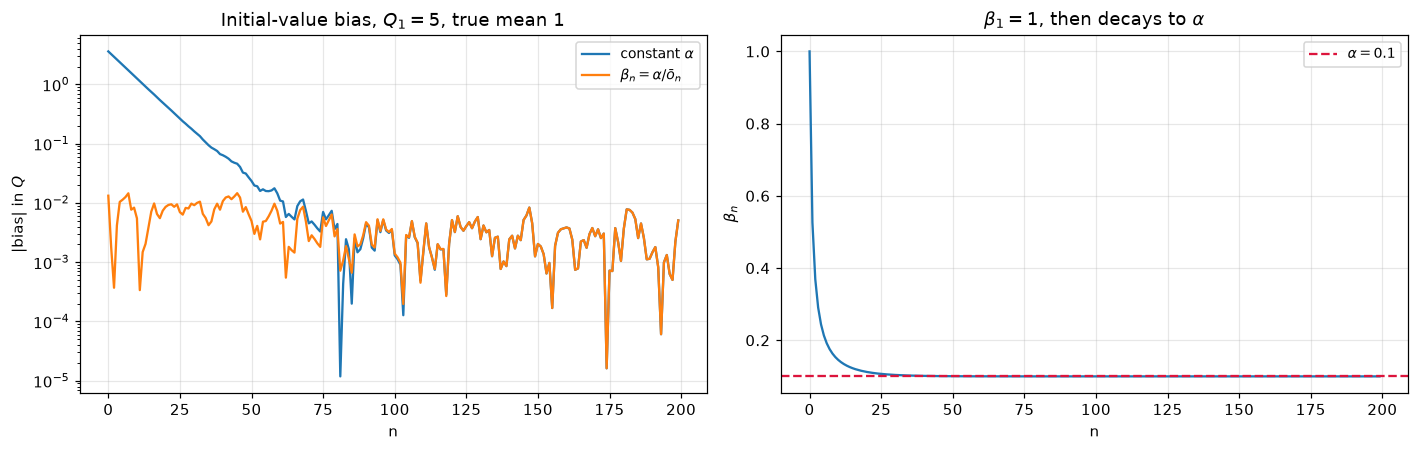

beta_1 = 1.0  beta_50 = 0.1005  beta_200 = 0.1
bias after 1 step:  constant alpha = 3.6013 | beta rule = 0.013247


In [8]:
def compare_beta(alpha=0.1, T=200, Q1=5.0, true_mean=1.0, trials=3000, seed=0):
    rng = np.random.default_rng(seed)
    R = rng.normal(true_mean, 1.0, size=(trials, T))
    Qc = np.full(trials, Q1); Qb = np.full(trials, Q1); o = 0.0
    ec, eb, betas = [], [], []
    for t in range(T):
        Qc += alpha * (R[:, t] - Qc)
        o += alpha * (1 - o)
        beta = alpha / o
        Qb += beta * (R[:, t] - Qb)
        ec.append(Qc.mean() - true_mean); eb.append(Qb.mean() - true_mean)
        betas.append(beta)
    return np.array(ec), np.array(eb), np.array(betas)

ec, eb, betas = compare_beta()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].plot(np.abs(ec), label="constant $\\alpha$")
axes[0].plot(np.abs(eb), label="$\\beta_n = \\alpha / \\bar{o}_n$")
axes[0].set_yscale("log"); axes[0].set_ylabel("|bias| in $Q$")
axes[0].set_title("Initial-value bias, $Q_1 = 5$, true mean 1")
axes[1].plot(betas); axes[1].axhline(0.1, ls="--", color="crimson",
                                     label="$\\alpha = 0.1$")
axes[1].set_ylabel("$\\beta_n$"); axes[1].set_title(r"$\beta_1 = 1$, then decays to $\alpha$")
for ax in axes:
    ax.set_xlabel("n"); ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("beta_1 =", round(betas[0], 6), " beta_50 =", round(betas[49], 4),
      " beta_200 =", round(betas[-1], 4))
print("bias after 1 step:  constant alpha =", round(abs(ec[0]), 4),
      "| beta rule =", round(abs(eb[0]), 6))

$\beta_1 = 1$ exactly, so the bias is annihilated on the first sample rather than decaying
as $(1-\alpha)^n$. Note $\bar o_n$ is a step-count-free trace — no $N(a)$ needed, which is
why this trick survives into function-approximation settings.

## Takeaways for 2.8

1. Gradient bandits learn **preferences**, not values; soft-max turns them into a policy.
2. The update is provably a stochastic gradient ascent step on $\mathbb{E}[R_t]$.
3. The baseline is free (unbiased) because $\sum_x \partial\pi_t(x)/\partial H_t(a) = 0$,
   and it cuts variance by roughly an order of magnitude when rewards are off-centre.
4. This is the direct ancestor of policy-gradient methods — REINFORCE with baseline is
   this algorithm with states attached.

**Next:** attach a state — Section 2.9.